# EEG Topographic Analysis - GSN-HydroCel-256 Examples

This notebook demonstrates the `eegtopo` package with two realistic EEG datasets using the **GSN-HydroCel-256 electrode montage**:

1. **Example with Significant Effect**: `example_with_effect_256.csv` - Shows a frontal alpha power increase in post vs pre condition
2. **Example with No Effect**: `example_no_effect_256.csv` - Random noise with no systematic differences

## Dataset Details

- **20 subjects** (sub-01 to sub-20)
- **259 channels** from GSN-HydroCel-256 system:
  - 256 EEG channels: E1-E256
  - 3 fiducial channels: FidNz, FidT9, FidT10
- **2 conditions**: pre, post
- **Value**: Alpha power (8-12 Hz)

**Montage**: GSN-HydroCel-256 (Geodesic Sensor Net with 256 electrodes)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the eegtopo package
from eegtopo import TopographicAnalysis, run_cluster_analysis

# Set up plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

---

# Example 1: Dataset WITH Significant Effect

This dataset simulates a frontal alpha effect where anterior channels (E1-E40) show increased alpha power in the post condition.

In [2]:
# Load the data with effect
df_effect = pd.read_csv('example_with_effect_256.csv')

print("Dataset 1: With Significant Effect (GSN-HydroCel-256)")
print("="*60)
print(f"Shape: {df_effect.shape}")
print(f"Subjects: {df_effect['subject'].nunique()}")
print(f"Total Channels: {df_effect['channel'].nunique()}")
print(f"Conditions: {df_effect['condition'].unique()}")
print(f"\nChannel types:")
print(f"  EEG channels (E1-E256): {len([c for c in df_effect['channel'].unique() if c.startswith('E')])}")
print(f"  Fiducials: {len([c for c in df_effect['channel'].unique() if c.startswith('Fid')])}")
print(f"\nFirst few rows:")
df_effect.head(10)

Dataset 1: With Significant Effect (GSN-HydroCel-256)
Shape: (10360, 4)
Subjects: 20
Total Channels: 259
Conditions: <StringArray>
['pre', 'post']
Length: 2, dtype: str

Channel types:
  EEG channels (E1-E256): 256
  Fiducials: 3

First few rows:


,subject,channel,condition,value
0,sub-01,FidNz,pre,10.7301
1,sub-01,FidNz,post,10.4313
2,sub-01,FidT9,pre,9.1991
3,sub-01,FidT9,post,7.2385
4,sub-01,FidT10,pre,6.5769
5,sub-01,FidT10,post,7.4384
6,sub-01,E1,pre,7.8017
7,sub-01,E1,post,12.3558
8,sub-01,E2,pre,10.7848
9,sub-01,E2,post,10.9343


### 1.1 Quick Analysis

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 256


/Users/idohaber/00_development/eegtopo/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



✓ Found 1 significant clusters

Cluster summary:


,cluster_id,n_channels,p_value,significant
0,1,1,0.998,False
1,2,1,0.999,False
2,3,1,0.999,False
3,4,40,0.001,True
4,5,2,0.189,False
5,6,1,0.999,False
6,7,1,0.886,False
7,8,1,0.878,False
8,9,1,0.986,False


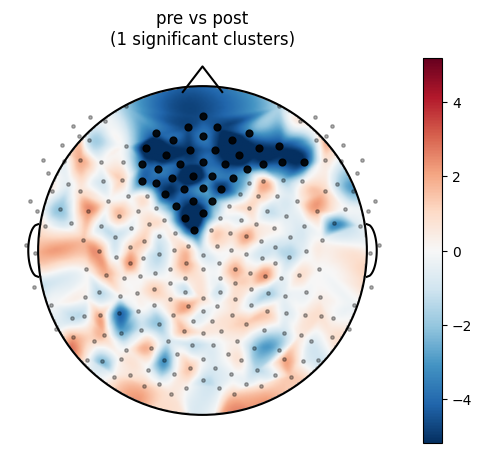

In [3]:
# Run one-shot analysis
results_effect = run_cluster_analysis(
    df_effect,
    condition_a='pre',
    condition_b='post',
    montage_name='GSN-HydroCel-256',
    threshold=None,  # Auto-compute from t-distribution
    n_permutations=1000,
    plot=True
)

print(f"\n✓ Found {results_effect['results'].n_sig_clusters} significant clusters")
print(f"\nCluster summary:")
results_effect['results'].summary()

### 1.2 Detailed Analysis with Object-Oriented Interface

In [4]:
# Create analysis object
analysis_effect = TopographicAnalysis(
    df_effect,
    subject_col='subject',
    channel_col='channel',
    value_col='value',
    condition_col='condition',
    montage_name='GSN-HydroCel-256'
)

print(f"Analysis ready with {len(analysis_effect.ordered_channels)} channels")
print(f"Sample channels: {analysis_effect.ordered_channels[:10]}")
print(f"Fiducials included: {[c for c in analysis_effect.ordered_channels if 'Fid' in c]}")

Analysis ready with 256 channels
Sample channels: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10']
Fiducials included: []


### 1.3 Compare Different Threshold Methods


Testing with Automatic (p<0.05)...
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 256
  Result: 1 significant clusters
  Frontal significant channels: 40

Testing with t > 2.0...
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 256
  Result: 1 significant clusters
  Frontal significant channels: 40

Testing with t > 2.5...
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 256
  Result: 1 significant clusters
  Frontal significant channels: 40


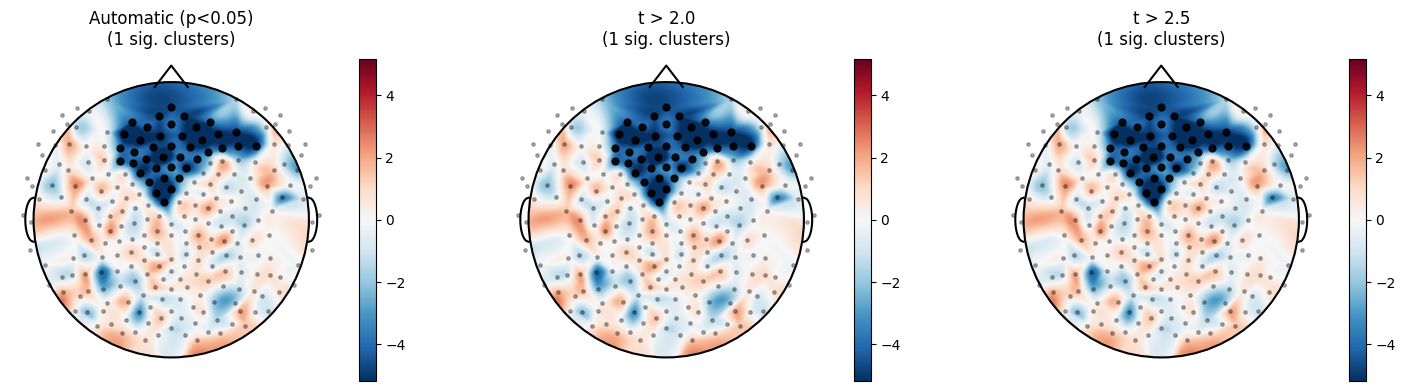

In [5]:
# Test different threshold methods
threshold_methods = [
    ('Automatic (p<0.05)', None),
    ('t > 2.0', 2.0),
    ('t > 2.5', 2.5),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (method_name, threshold) in enumerate(threshold_methods):
    print(f"\nTesting with {method_name}...")
    
    result = analysis_effect.run_cluster_test(
        'pre', 'post',
        threshold=threshold,
        n_permutations=1000
    )
    
    analysis_effect.plot_cluster_results(
        result,
        ax=axes[idx],
        title=f"{method_name}\n({result.n_sig_clusters} sig. clusters)"
    )
    
    print(f"  Result: {result.n_sig_clusters} significant clusters")
    if result.sig_channels:
        sig_frontal = [c for c in result.sig_channels if c.startswith('E') and int(c[1:]) <= 40]
        print(f"  Frontal significant channels: {len(sig_frontal)}")

plt.tight_layout()
plt.savefig('example_256_effect_threshold_comparison.png', dpi=150)
plt.show()

### 1.4 Visualize Mean Topomaps

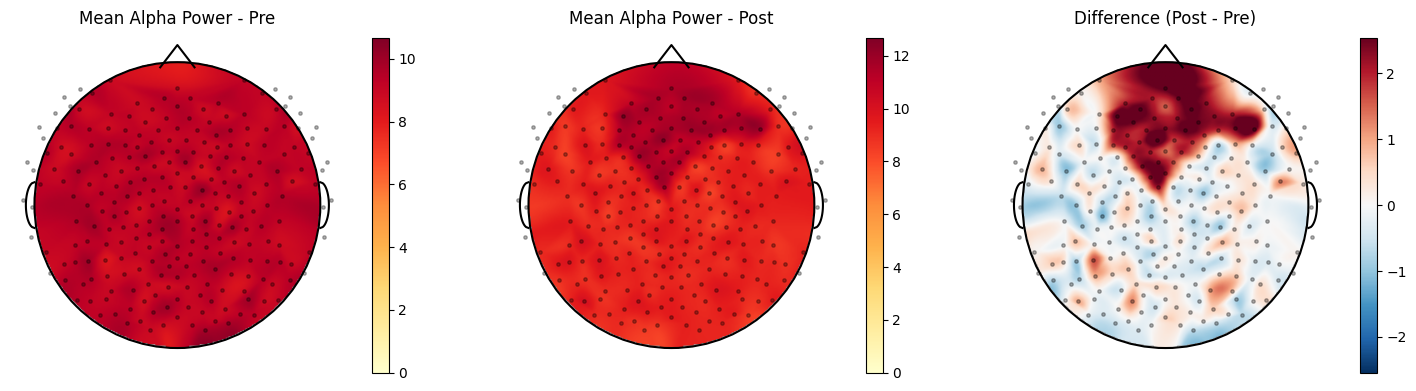

In [6]:
# Plot mean topomaps for both conditions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pre condition
analysis_effect.plot_mean_topomap(
    condition='pre',
    ax=axes[0],
    title='Mean Alpha Power - Pre',
    cmap='YlOrRd'
)

# Post condition
analysis_effect.plot_mean_topomap(
    condition='post',
    ax=axes[1],
    title='Mean Alpha Power - Post',
    cmap='YlOrRd'
)

# Difference
pre_means = df_effect[df_effect['condition'] == 'pre'].groupby('channel')['value'].mean()
post_means = df_effect[df_effect['condition'] == 'post'].groupby('channel')['value'].mean()
difference = (post_means - pre_means).to_dict()

analysis_effect.plot_topomap(
    difference,
    ax=axes[2],
    title='Difference (Post - Pre)',
    cmap='RdBu_r'
)

plt.tight_layout()
plt.savefig('example_256_effect_means.png', dpi=150)
plt.show()

---

# Example 2: Dataset WITHOUT Significant Effect

This dataset contains pure random noise with no systematic differences between conditions. This demonstrates what null results look like with the full 256-channel montage.

In [7]:
# Load the data without effect
df_no_effect = pd.read_csv('example_no_effect_256.csv')

print("Dataset 2: Without Significant Effect (GSN-HydroCel-256 Null Data)")
print("="*60)
print(f"Shape: {df_no_effect.shape}")
print(f"Subjects: {df_no_effect['subject'].nunique()}")
print(f"Total Channels: {df_no_effect['channel'].nunique()}")
print(f"Conditions: {df_no_effect['condition'].unique()}")
print(f"\nFirst few rows:")
df_no_effect.head(10)

Dataset 2: Without Significant Effect (GSN-HydroCel-256 Null Data)
Shape: (10360, 4)
Subjects: 20
Total Channels: 259
Conditions: <StringArray>
['pre', 'post']
Length: 2, dtype: str

First few rows:


,subject,channel,condition,value
0,sub-01,FidNz,pre,7.3786
1,sub-01,FidNz,post,7.4410
2,sub-01,FidT9,pre,6.9611
3,sub-01,FidT9,post,7.9392
4,sub-01,FidT10,pre,7.8205
5,sub-01,FidT10,post,6.5996
6,sub-01,E1,pre,7.2048
7,sub-01,E1,post,7.3340
8,sub-01,E2,pre,7.7296
9,sub-01,E2,post,8.0155


### 2.1 Quick Analysis

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 256

✓ Found 0 significant clusters

Cluster summary:


,cluster_id,n_channels,p_value,significant
0,1,1,1.000,False
1,2,1,0.882,False
2,3,1,0.999,False
3,4,1,0.935,False
4,5,2,0.417,False
5,6,1,0.939,False


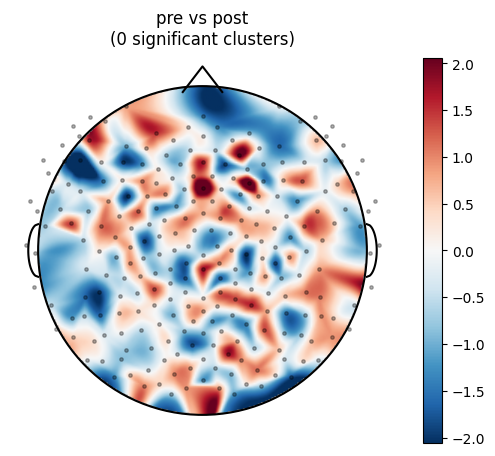

In [8]:
# Run one-shot analysis on null data
results_no_effect = run_cluster_analysis(
    df_no_effect,
    condition_a='pre',
    condition_b='post',
    montage_name='GSN-HydroCel-256',
    threshold=None,
    n_permutations=1000,
    plot=True
)

print(f"\n✓ Found {results_no_effect['results'].n_sig_clusters} significant clusters")
print(f"\nCluster summary:")
results_no_effect['results'].summary()

### 2.2 Detailed Analysis

In [9]:
# Create analysis object for null data
analysis_no_effect = TopographicAnalysis(
    df_no_effect,
    subject_col='subject',
    channel_col='channel',
    value_col='value',
    condition_col='condition',
    montage_name='GSN-HydroCel-256'
)

# Run cluster test
result_no_effect = analysis_no_effect.run_cluster_test(
    'pre', 'post',
    n_permutations=1000
)

print(f"\nCluster test results:")
print(f"  Total clusters found: {len(result_no_effect.clusters)}")
print(f"  Significant clusters (p<0.05): {result_no_effect.n_sig_clusters}")
print(f"  Significant channels: {len(result_no_effect.sig_channels)}")

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 256

Cluster test results:
  Total clusters found: 6
  Significant clusters (p<0.05): 0
  Significant channels: 0


### 2.3 Visualize Null Results

In [ ]:
# Plot results for null data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# T-statistic map
analysis_no_effect.plot_cluster_results(
    result_no_effect,
    ax=axes[0],
    title=(f"T-statistic Map\n({result_no_effect.n_sig_clusters} significant clusters))"
    cmap='RdBu_r'
)

# Difference map
pre_means_null = df_no_effect[df_no_effect['condition'] == 'pre'].groupby('channel')['value'].mean()
post_means_null = df_no_effect[df_no_effect['condition'] == 'post'].groupby('channel')['value'].mean()
difference_null = (post_means_null - pre_means_null).to_dict()

analysis_no_effect.plot_topomap(
    difference_null,
    ax=axes[1],
    title='Difference (Post - Pre)\n(Random noise)',
    cmap='RdBu_r'
)

plt.tight_layout()
plt.savefig('example_256_no_effect_results.png', dpi=150)
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3827090287.py, line 8)

---

# Side-by-Side Comparison

In [ ]:
# Compare both datasets side-by-side
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: With Effect
result_effect = analysis_effect.run_cluster_test('pre', 'post', n_permutations=1000)

analysis_effect.plot_mean_topomap('pre', ax=axes[0,0], title='With Effect: Pre', cmap='YlOrRd')
analysis_effect.plot_mean_topomap('post', ax=axes[0,1], title='With Effect: Post', cmap='YlOrRd')
analysis_effect.plot_cluster_results(
    result_effect, 
    ax=axes[0,2], 
    title=f"With Effect: Clusters\n({result_effect.n_sig_clusters} significant)"
)

# Row 2: Without Effect
analysis_no_effect.plot_mean_topomap('pre', ax=axes[1,0], title='No Effect: Pre', cmap='YlOrRd')
analysis_no_effect.plot_mean_topomap('post', ax=axes[1,1], title='No Effect: Post', cmap='YlOrRd')
analysis_no_effect.plot_cluster_results(
    result_no_effect, 
    ax=axes[1,2], 
    title=f"No Effect: Clusters\n({result_no_effect.n_sig_clusters} significant)"
)

plt.tight_layout()
plt.savefig('comparison_256_both_examples.png', dpi=150)
plt.show()

---

# Export Results

In [ ]:
# Export cluster summaries for both datasets
print("Exporting results to CSV...")

# With effect
summary_effect = result_effect.summary()
summary_effect.to_csv('cluster_summary_256_with_effect.csv', index=False)
print(f"✓ Saved cluster_summary_256_with_effect.csv")

# Without effect
summary_no_effect = result_no_effect.summary()
summary_no_effect.to_csv('cluster_summary_256_no_effect.csv', index=False)
print(f"✓ Saved cluster_summary_256_no_effect.csv")

# Export per-channel t-statistics
stats_effect = pd.DataFrame({
    'channel': analysis_effect.ordered_channels,
    't_statistic': result_effect.t_obs,
    'significant': result_effect.sig_mask
})
stats_effect.to_csv('channel_statistics_256_with_effect.csv', index=False)
print(f"✓ Saved channel_statistics_256_with_effect.csv")

stats_no_effect = pd.DataFrame({
    'channel': analysis_no_effect.ordered_channels,
    't_statistic': result_no_effect.t_obs,
    'significant': result_no_effect.sig_mask
})
stats_no_effect.to_csv('channel_statistics_256_no_effect.csv', index=False)
print(f"✓ Saved channel_statistics_256_no_effect.csv")

print("\nAll exports complete!")

---

# Summary

## Key Takeaways

1. **With Effect Dataset (GSN-HydroCel-256)**:
   - Shows clear frontal alpha power increase in anterior channels
   - Cluster test finds significant clusters concentrated in frontal areas
   - T-statistics are large and spatially contiguous
   - Effect size: ~30% increase in frontal channels (E1-E40)

2. **Without Effect Dataset (GSN-HydroCel-256)**:
   - Random noise across all 256 channels
   - No significant clusters found
   - T-statistics are small and randomly distributed
   - Demonstrates proper control of false positive rate

3. **Package Features Demonstrated**:
   - Full 256-channel montage support
   - Automatic handling of fiducial channels (FidNz, FidT9, FidT10)
   - High-density EEG visualization
   - Flexible threshold handling
   - Publication-quality topographic maps
   - Comprehensive result export

## Technical Notes

- **Montage**: GSN-HydroCel-256 with azimuthal equidistant projection
- **Spatial Adjacency**: Computed automatically from channel positions
- **Cluster Formation**: Based on t-statistics with spatial adjacency
- **Multiple Comparisons**: Controlled via cluster-based permutation testing

## Next Steps

- Try with your own high-density EEG data
- Experiment with different frequency bands (theta, beta, gamma)
- Adjust `n_permutations` for more statistical power (e.g., 10000)
- Use `exclude_channels` to remove noisy electrodes
- Try other montages (GSN-HydroCel-128, Biosemi, etc.)